<a href="https://colab.research.google.com/github/Ajwad07/ML_projects_/blob/main/AE_Cifar10_Conv_vs_Depthwise_vs_DepthwiseCBAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn

# ---------- Depthwise Separable Convolution Module ----------
class DepthwiseSeparableConv(nn.Module):
    """
    Depthwise separable convolution:
    - Depthwise: groups=in_channels
    - Pointwise: 1x1 conv
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(
            in_channels, in_channels, kernel_size,
            stride, padding, groups=in_channels, bias=False
        )
        self.pointwise = nn.Conv2d(
            in_channels, out_channels, 1,
            1, 0, bias=False
        )
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

# ---------- Basic CBAM for 2D feature maps ----------
class BasicCBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        # Channel attention
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        # Spatial attention
        self.spatial = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False),
            nn.Sigmoid()
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        # Channel attention
        avg_out = self.mlp(self.avg_pool(x).view(x.size(0), -1))
        max_out = self.mlp(self.max_pool(x).view(x.size(0), -1))
        ch_attn = self.sigmoid(avg_out + max_out).view(x.size(0), x.size(1), 1, 1)
        x = x * ch_attn
        # Spatial attention
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        sp_attn = self.spatial(torch.cat([avg_out, max_out], dim=1))
        x = x * sp_attn
        return x

# ---------- Regular Conv Autoencoder ----------
class RegularConvAE(nn.Module):
    """
    Baseline: All regular Conv2d in encoder and ConvTranspose2d in decoder.
    """
    def __init__(self):
        super().__init__()
        # Encoder: regular conv
        self.enc1 = nn.Conv2d(3, 16, 3, stride=2, padding=1)
        self.enc2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.enc3 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        # Decoder: regular deconv
        self.dec1 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)
        self.dec2 = nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1)
        self.dec3 = nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.tanh = nn.Tanh()
    def forward(self, x):
        x = self.relu(self.enc1(x))
        x = self.relu(self.enc2(x))
        x = self.relu(self.enc3(x))
        x = self.relu(self.dec1(x))
        x = self.relu(self.dec2(x))
        x = self.tanh(self.dec3(x))
        return x

# ---------- Depthwise Separable Conv Autoencoder ----------
class DepthwiseConvAE(nn.Module):
    """
    All Conv2d replaced with DepthwiseSeparableConv in encoder.
    Decoder remains regular ConvTranspose2d.
    """
    def __init__(self):
        super().__init__()
        # Encoder: depthwise separable conv
        self.enc1 = DepthwiseSeparableConv(3, 16, 3, stride=2, padding=1)
        self.enc2 = DepthwiseSeparableConv(16, 32, 3, stride=2, padding=1)
        self.enc3 = DepthwiseSeparableConv(32, 64, 3, stride=2, padding=1)
        # Decoder: regular deconv
        self.dec1 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)
        self.dec2 = nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1)
        self.dec3 = nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.tanh = nn.Tanh()
    def forward(self, x):
        x = self.relu(self.enc1(x))
        x = self.relu(self.enc2(x))
        x = self.relu(self.enc3(x))
        x = self.relu(self.dec1(x))
        x = self.relu(self.dec2(x))
        x = self.tanh(self.dec3(x))
        return x

# ---------- Depthwise Separable Conv + CBAM Autoencoder ----------
class DepthwiseCBAMAE(nn.Module):
    """
    Encoder: depthwise separable conv + CBAM after each block.
    Decoder: regular ConvTranspose2d.
    """
    def __init__(self):
        super().__init__()
        # Encoder: depthwise separable + CBAM
        self.enc1 = DepthwiseSeparableConv(3, 16, 3, stride=2, padding=1)
        self.cbam1 = BasicCBAM(16)
        self.enc2 = DepthwiseSeparableConv(16, 32, 3, stride=2, padding=1)
        self.cbam2 = BasicCBAM(32)
        self.enc3 = DepthwiseSeparableConv(32, 64, 3, stride=2, padding=1)
        self.cbam3 = BasicCBAM(64)
        # Decoder: regular deconv
        self.dec1 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)
        self.dec2 = nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1)
        self.dec3 = nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.tanh = nn.Tanh()
    def forward(self, x):
        x = self.relu(self.cbam1(self.enc1(x)))
        x = self.relu(self.cbam2(self.enc2(x)))
        x = self.relu(self.cbam3(self.enc3(x)))
        x = self.relu(self.dec1(x))
        x = self.relu(self.dec2(x))
        x = self.tanh(self.dec3(x))
        return x

# ---------- Utility: Parameter Count ----------
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ---------- Demo: Print parameter counts ----------
if __name__ == "__main__":
    dummy = torch.randn(1, 3, 32, 32)
    models = [
        ('RegularConvAE', RegularConvAE()),
        ('DepthwiseConvAE', DepthwiseConvAE()),
        ('DepthwiseCBAMAE', DepthwiseCBAMAE())
    ]
    for name, model in models:
        print(f"{name} param count: {count_params(model):,}")
        with torch.no_grad():
            out = model(dummy)
            print(f"{name} output shape: {out.shape}")

RegularConvAE param count: 47,107
RegularConvAE output shape: torch.Size([1, 3, 32, 32])
DepthwiseConvAE param count: 26,590
DepthwiseConvAE output shape: torch.Size([1, 3, 32, 32])
DepthwiseCBAMAE param count: 27,556
DepthwiseCBAMAE output shape: torch.Size([1, 3, 32, 32])


# CIFAR-10: Conv vs Depthwise vs Depthwise+CBAM Autoencoders

**Compare parameter count and reconstruction quality:**
- Baseline: regular conv encoder
- Depthwise separable conv encoder
- Depthwise separable conv encoder + CBAM

*Includes training, evaluation, and visualization.*

In [2]:
! pip install pytorch_msssim

In [3]:
# --- Imports ---
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from pytorch_msssim import ssim
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Data: CIFAR-10
- Normalized to [-1, 1]

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

## CBAM Block (for use in encoder)

In [5]:
class BasicCBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        # Channel attention
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        # Spatial attention
        self.spatial = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False),
            nn.Sigmoid()
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Channel attention
        avg_out = self.mlp(self.avg_pool(x).view(x.size(0), -1))
        max_out = self.mlp(self.max_pool(x).view(x.size(0), -1))
        ch_attn = self.sigmoid(avg_out + max_out).view(x.size(0), x.size(1), 1, 1)
        x = x * ch_attn
        # Spatial attention
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        sp_attn = self.spatial(torch.cat([avg_out, max_out], dim=1))
        x = x * sp_attn
        return x

## Depthwise Separable Conv

In [6]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(
            in_channels, in_channels, kernel_size, stride, padding, groups=in_channels, bias=False
        )
        self.pointwise = nn.Conv2d(
            in_channels, out_channels, 1, 1, 0, bias=False
        )
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

## Model Variants
- RegularConvAE: regular conv
- DepthwiseConvAE: depthwise separable conv
- DepthwiseCBAMAE: depthwise + CBAM

In [7]:
class RegularConvAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Conv2d(3, 16, 3, stride=2, padding=1)
        self.enc2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.enc3 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.dec1 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)
        self.dec2 = nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1)
        self.dec3 = nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1)
        self.relu = nn.ReLU(True)
        self.tanh = nn.Tanh()
    def forward(self, x):
        x = self.relu(self.enc1(x))
        x = self.relu(self.enc2(x))
        x = self.relu(self.enc3(x))
        x = self.relu(self.dec1(x))
        x = self.relu(self.dec2(x))
        x = self.tanh(self.dec3(x))
        return x

class DepthwiseConvAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DepthwiseSeparableConv(3, 16, 3, stride=2, padding=1)
        self.enc2 = DepthwiseSeparableConv(16, 32, 3, stride=2, padding=1)
        self.enc3 = DepthwiseSeparableConv(32, 64, 3, stride=2, padding=1)
        self.dec1 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)
        self.dec2 = nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1)
        self.dec3 = nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1)
        self.relu = nn.ReLU(True)
        self.tanh = nn.Tanh()
    def forward(self, x):
        x = self.relu(self.enc1(x))
        x = self.relu(self.enc2(x))
        x = self.relu(self.enc3(x))
        x = self.relu(self.dec1(x))
        x = self.relu(self.dec2(x))
        x = self.tanh(self.dec3(x))
        return x

class DepthwiseCBAMAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DepthwiseSeparableConv(3, 16, 3, stride=2, padding=1)
        self.cbam1 = BasicCBAM(16)
        self.enc2 = DepthwiseSeparableConv(16, 32, 3, stride=2, padding=1)
        self.cbam2 = BasicCBAM(32)
        self.enc3 = DepthwiseSeparableConv(32, 64, 3, stride=2, padding=1)
        self.cbam3 = BasicCBAM(64)
        self.dec1 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)
        self.dec2 = nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1)
        self.dec3 = nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1)
        self.relu = nn.ReLU(True)
        self.tanh = nn.Tanh()
    def forward(self, x):
        x = self.relu(self.cbam1(self.enc1(x)))
        x = self.relu(self.cbam2(self.enc2(x)))
        x = self.relu(self.cbam3(self.enc3(x)))
        x = self.relu(self.dec1(x))
        x = self.relu(self.dec2(x))
        x = self.tanh(self.dec3(x))
        return x

## Utilities: params, SSIM, recon plot

In [8]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def batch_ssim(x, y):
    return ssim(x, y, data_range=2, size_average=True).item()

def plot_recon(images, recons, n=10, suptitle=None):
    images = (images.cpu().detach().numpy() + 1) / 2
    recons = (recons.cpu().detach().numpy() + 1) / 2
    fig, axes = plt.subplots(2, n, figsize=(n*1.2, 3))
    for i in range(n):
        axes[0, i].imshow(np.transpose(images[i], (1,2,0)))
        axes[0, i].axis('off')
        axes[1, i].imshow(np.transpose(recons[i], (1,2,0)))
        axes[1, i].axis('off')
    if suptitle: plt.suptitle(suptitle)
    plt.show()

## Training loop
- Uses MSE + SSIM loss (weighted sum)
- Returns train/test loss, test SSIM per epoch

In [9]:
def train_model(model, train_loader, test_loader, epochs=10, lr=2e-4, alpha_ssim=0.1, verbose=True):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-9)
    mse_loss = nn.MSELoss()
    train_losses, test_losses, test_ssims = [], [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            loss_mse = mse_loss(outputs, imgs)
            loss_ssim = 1 - ssim(outputs, imgs, data_range=2, size_average=True)
            loss = loss_mse + alpha_ssim * loss_ssim
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        avg_loss = running_loss / len(train_loader.dataset)
        train_losses.append(avg_loss)
        # --- Validation ---
        model.eval()
        test_loss, test_ssim_acc = 0.0, 0.0
        with torch.no_grad():
            for imgs, _ in test_loader:
                imgs = imgs.to(device)
                outputs = model(imgs)
                loss_mse = mse_loss(outputs, imgs)
                loss_ssim = 1 - ssim(outputs, imgs, data_range=2, size_average=True)
                loss = loss_mse + alpha_ssim * loss_ssim
                test_loss += loss.item() * imgs.size(0)
                test_ssim_acc += batch_ssim(outputs, imgs) * imgs.size(0)
        test_losses.append(test_loss / len(test_loader.dataset))
        test_ssims.append(test_ssim_acc / len(test_loader.dataset))
        if verbose:
            print(f"Epoch {epoch+1}: TrainLoss={avg_loss:.4f}, TestLoss={test_losses[-1]:.4f}, TestSSIM={test_ssims[-1]:.4f}")
    return train_losses, test_losses, test_ssims

## Train all models
- Each for 10 epochs (adjust if needed)

In [13]:
# --- Baseline ---
model_base = RegularConvAE()
print(f"Baseline ConvAE params: {count_params(model_base)/1e3:.1f}K")
train_losses_b, test_losses_b, test_ssim_b = train_model(model_base, train_loader, test_loader, epochs=30)

# --- Depthwise ---
model_dw = DepthwiseConvAE()
print(f"DepthwiseConvAE params: {count_params(model_dw)/1e3:.1f}K")
train_losses_dw, test_losses_dw, test_ssim_dw = train_model(model_dw, train_loader, test_loader, epochs=30)

# --- Depthwise + CBAM ---
model_cbam = DepthwiseCBAMAE()
print(f"DepthwiseCBAMAE params: {count_params(model_cbam)/1e3:.1f}K")
train_losses_c, test_losses_c, test_ssim_c = train_model(model_cbam, train_loader, test_loader, epochs=30)

Baseline ConvAE params: 47.1K
Epoch 1: TrainLoss=0.1876, TestLoss=0.1039, TestSSIM=0.4919
Epoch 2: TrainLoss=0.0828, TestLoss=0.0688, TestSSIM=0.6362
Epoch 3: TrainLoss=0.0629, TestLoss=0.0583, TestSSIM=0.6847
Epoch 4: TrainLoss=0.0556, TestLoss=0.0529, TestSSIM=0.7117
Epoch 5: TrainLoss=0.0515, TestLoss=0.0496, TestSSIM=0.7281
Epoch 6: TrainLoss=0.0489, TestLoss=0.0475, TestSSIM=0.7387
Epoch 7: TrainLoss=0.0469, TestLoss=0.0459, TestSSIM=0.7471
Epoch 8: TrainLoss=0.0455, TestLoss=0.0454, TestSSIM=0.7477
Epoch 9: TrainLoss=0.0441, TestLoss=0.0433, TestSSIM=0.7599
Epoch 10: TrainLoss=0.0429, TestLoss=0.0421, TestSSIM=0.7657
Epoch 11: TrainLoss=0.0416, TestLoss=0.0406, TestSSIM=0.7736
Epoch 12: TrainLoss=0.0401, TestLoss=0.0391, TestSSIM=0.7811
Epoch 13: TrainLoss=0.0385, TestLoss=0.0385, TestSSIM=0.7822
Epoch 14: TrainLoss=0.0370, TestLoss=0.0362, TestSSIM=0.7981
Epoch 15: TrainLoss=0.0361, TestLoss=0.0369, TestSSIM=0.7904
Epoch 16: TrainLoss=0.0353, TestLoss=0.0355, TestSSIM=0.7997
Epo

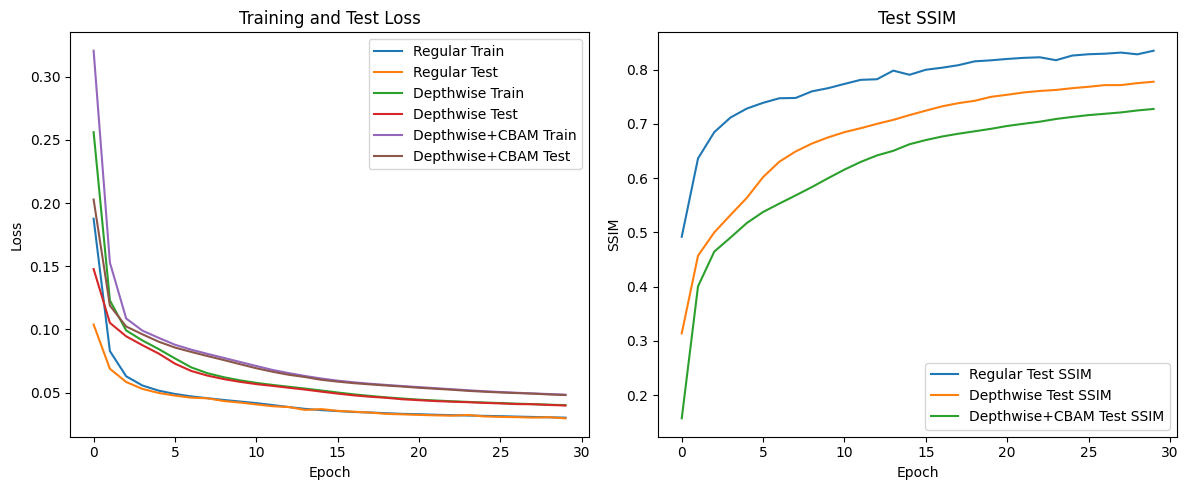


Reconstructions for RegularConvAE:


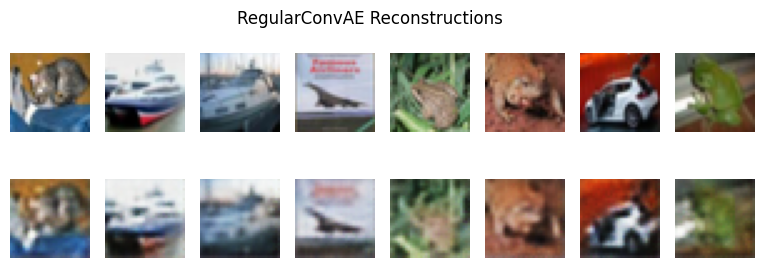


Reconstructions for DepthwiseConvAE:


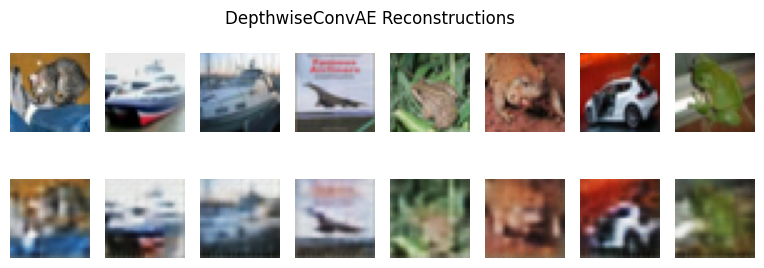


Reconstructions for DepthwiseCBAMAE:


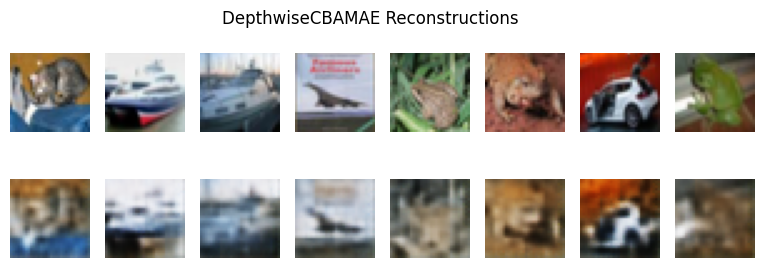

In [16]:
# prompt: extract losses and values from previous cels outut and plot them

# Assuming the training output from the previous cell is available
# The variables storing the losses and SSIMs are:
# train_losses_b, test_losses_b, test_ssim_b  (for RegularConvAE)
# train_losses_dw, test_losses_dw, test_ssim_dw (for DepthwiseConvAE)
# train_losses_c, test_losses_c, test_ssim_c  (for DepthwiseCBAMAE)

import matplotlib.pyplot as plt
import numpy as np

# Plotting the training and testing losses
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_b, label='Regular Train')
plt.plot(test_losses_b, label='Regular Test')
plt.plot(train_losses_dw, label='Depthwise Train')
plt.plot(test_losses_dw, label='Depthwise Test')
plt.plot(train_losses_c, label='Depthwise+CBAM Train')
plt.plot(test_losses_c, label='Depthwise+CBAM Test')
plt.title('Training and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting the test SSIM
plt.subplot(1, 2, 2)
plt.plot(test_ssim_b, label='Regular Test SSIM')
plt.plot(test_ssim_dw, label='Depthwise Test SSIM')
plt.plot(test_ssim_c, label='Depthwise+CBAM Test SSIM')
plt.title('Test SSIM')
plt.xlabel('Epoch')
plt.ylabel('SSIM')
plt.legend()

plt.tight_layout()
plt.show()

# Optional: Visualize reconstructions for a batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)

print("\nReconstructions for RegularConvAE:")
with torch.no_grad():
    recon_b = model_base(images)
plot_recon(images.cpu(), recon_b.cpu(), n=8, suptitle='RegularConvAE Reconstructions')

print("\nReconstructions for DepthwiseConvAE:")
with torch.no_grad():
    recon_dw = model_dw(images)
plot_recon(images.cpu(), recon_dw.cpu(), n=8, suptitle='DepthwiseConvAE Reconstructions')

print("\nReconstructions for DepthwiseCBAMAE:")
with torch.no_grad():
    recon_c = model_cbam(images)
plot_recon(images.cpu(), recon_c.cpu(), n=8, suptitle='DepthwiseCBAMAE Reconstructions')

In [17]:
# prompt: analysis on how much loss we are accepting vs how much lower the parameter count is the tradeoff ratio

# --- Analysis of Tradeoff ---

# Get final test SSIM and parameter counts
final_ssim_b = test_ssim_b[-1]
final_ssim_dw = test_ssim_dw[-1]
final_ssim_c = test_ssim_c[-1]

params_b = count_params(model_base)
params_dw = count_params(model_dw)
params_c = count_params(model_cbam)

print("\n--- Tradeoff Analysis ---")
print(f"RegularConvAE: Params={params_b:,}, Final Test SSIM={final_ssim_b:.4f}")
print(f"DepthwiseConvAE: Params={params_dw:,}, Final Test SSIM={final_ssim_dw:.4f}")
print(f"DepthwiseCBAMAE: Params={params_c:,}, Final Test SSIM={final_ssim_c:.4f}")

# Calculate percentage reduction in parameters compared to baseline
param_reduction_dw = ((params_b - params_dw) / params_b) * 100
param_reduction_c = ((params_b - params_c) / params_b) * 100

# Calculate the loss in SSIM compared to baseline
# Note: SSIM is a similarity metric, higher is better.
# Loss in "quality" can be viewed as the decrease in SSIM.
ssim_loss_dw = final_ssim_b - final_ssim_dw
ssim_loss_c = final_ssim_b - final_ssim_c

print(f"\nDepthwiseConvAE vs RegularConvAE:")
print(f"  Parameter Reduction: {param_reduction_dw:.2f}%")
print(f"  SSIM Difference (lower is better): {ssim_loss_dw:.4f}")

print(f"\nDepthwiseCBAMAE vs RegularConvAE:")
print(f"  Parameter Reduction: {param_reduction_c:.2f}%")
print(f"  SSIM Difference (lower is better): {ssim_loss_c:.4f}")

# Calculate the tradeoff ratio (e.g., % param reduction / % loss in SSIM relative to baseline)
# A simple ratio might be (param_reduction / abs(ssim_difference * 100))
# or more meaningfully, (param_reduction / relative SSIM drop)
# Relative SSIM drop = (SSIM_baseline - SSIM_variant) / SSIM_baseline
relative_ssim_drop_dw = ssim_loss_dw / final_ssim_b if final_ssim_b != 0 else float('inf')
relative_ssim_drop_c = ssim_loss_c / final_ssim_b if final_ssim_b != 0 else float('inf')

print("\nTradeoff Ratio (Percentage Parameter Reduction / Relative SSIM Drop):")
# Avoid division by zero or very small numbers if SSIM drop is negligible
tradeoff_ratio_dw = param_reduction_dw / (relative_ssim_drop_dw * 100) if relative_ssim_drop_dw != 0 else float('inf')
tradeoff_ratio_c = param_reduction_c / (relative_ssim_drop_c * 100) if relative_ssim_drop_c != 0 else float('inf')

print(f"  DepthwiseConvAE: {tradeoff_ratio_dw:.2f} (higher is better)")
print(f"  DepthwiseCBAMAE: {tradeoff_ratio_c:.2f} (higher is better)")

# Another way to look at the ratio: How many times smaller is the model for each unit of SSIM loss?
params_ratio_dw = params_b / params_dw if params_dw != 0 else float('inf')
params_ratio_c = params_b / params_c if params_c != 0 else float('inf')

print("\nAlternative Tradeoff Ratio (Parameter Factor Reduction / SSIM Difference):")
# Avoid division by zero or very small numbers if SSIM difference is negligible
alt_tradeoff_ratio_dw = params_ratio_dw / ssim_loss_dw if ssim_loss_dw > 1e-6 else float('inf')
alt_tradeoff_ratio_c = params_ratio_c / ssim_loss_c if ssim_loss_c > 1e-6 else float('inf')

print(f"  DepthwiseConvAE: {alt_tradeoff_ratio_dw:.2f} (higher is better)")
print(f"  DepthwiseCBAMAE: {alt_tradeoff_ratio_c:.2f} (higher is better)")

# Interpretation:
print("\nInterpretation:")
print("- The 'Parameter Reduction' shows how much smaller the model is compared to the baseline.")
print("- The 'SSIM Difference' shows how much the image reconstruction quality (SSIM) decreased compared to the baseline.")
print("- A simple 'Tradeoff Ratio' (Percentage Parameter Reduction / Relative SSIM Drop) indicates how many percentage points of parameter reduction you get for each percentage point of relative SSIM loss. A higher value suggests a good tradeoff where you get significant parameter reduction for a small relative drop in SSIM.")
print("- The 'Alternative Tradeoff Ratio' (Parameter Factor Reduction / SSIM Difference) indicates how many times smaller the model is for each unit decrease in SSIM. Again, a higher value suggests a favorable tradeoff.")
print("\nBased on these metrics, you can assess which model variant offers a better balance between model size and reconstruction quality.")



--- Tradeoff Analysis ---
RegularConvAE: Params=47,107, Final Test SSIM=0.8348
DepthwiseConvAE: Params=26,590, Final Test SSIM=0.7776
DepthwiseCBAMAE: Params=27,556, Final Test SSIM=0.7274

DepthwiseConvAE vs RegularConvAE:
  Parameter Reduction: 43.55%
  SSIM Difference (lower is better): 0.0571

DepthwiseCBAMAE vs RegularConvAE:
  Parameter Reduction: 41.50%
  SSIM Difference (lower is better): 0.1074

Tradeoff Ratio (Percentage Parameter Reduction / Relative SSIM Drop):
  DepthwiseConvAE: 6.36 (higher is better)
  DepthwiseCBAMAE: 3.23 (higher is better)

Alternative Tradeoff Ratio (Parameter Factor Reduction / SSIM Difference):
  DepthwiseConvAE: 31.01 (higher is better)
  DepthwiseCBAMAE: 15.92 (higher is better)

Interpretation:
- The 'Parameter Reduction' shows how much smaller the model is compared to the baseline.
- The 'SSIM Difference' shows how much the image reconstruction quality (SSIM) decreased compared to the baseline.
- A simple 'Tradeoff Ratio' (Percentage Parameter

## Show reconstruction samples

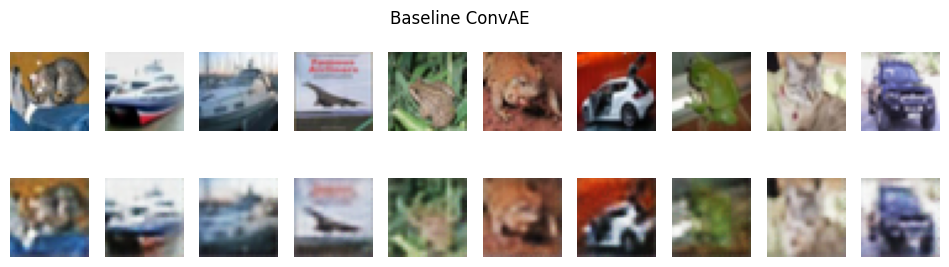

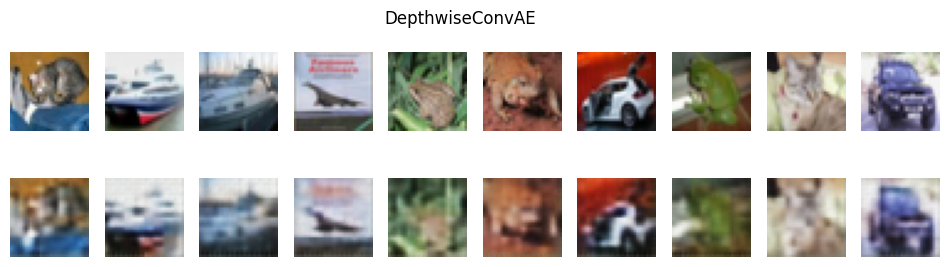

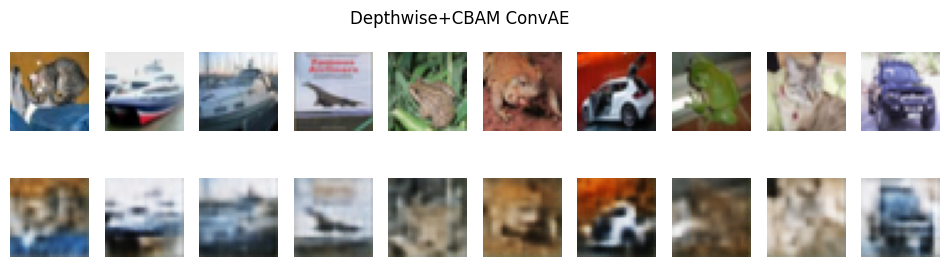

In [14]:
imgs, _ = next(iter(test_loader))
imgs = imgs.to(device)
model_base.eval(); model_dw.eval(); model_cbam.eval()
recon_b = model_base(imgs)
recon_dw = model_dw(imgs)
recon_c = model_cbam(imgs)
plot_recon(imgs, recon_b, n=10, suptitle='Baseline ConvAE')
plot_recon(imgs, recon_dw, n=10, suptitle='DepthwiseConvAE')
plot_recon(imgs, recon_c, n=10, suptitle='Depthwise+CBAM ConvAE')

## Compare Results

In [15]:
print("Summary Table:")
print(f"{'Model':<18}{'Params(K)':<13}{'Final Test Loss':<18}{'Final SSIM':<12}")
print(f"{'Baseline':<18}{count_params(model_base)/1e3:<13.1f}{test_losses_b[-1]:<18.4f}{test_ssim_b[-1]:<12.4f}")
print(f"{'Depthwise':<18}{count_params(model_dw)/1e3:<13.1f}{test_losses_dw[-1]:<18.4f}{test_ssim_dw[-1]:<12.4f}")
print(f"{'Depthwise+CBAM':<18}{count_params(model_cbam)/1e3:<13.1f}{test_losses_c[-1]:<18.4f}{test_ssim_c[-1]:<12.4f}")

Summary Table:
Model             Params(K)    Final Test Loss   Final SSIM  
Baseline          47.1         0.0296            0.8348      
Depthwise         26.6         0.0397            0.7776      
Depthwise+CBAM    27.6         0.0480            0.7274      
